 Problem Statement

The objective of this project is to analyze historical stock price data of major technology companies (Apple, Microsoft, Netflix, Google) to:

Understand price behavior and trading patterns

Analyze volatility and correlations

Build machine learning models to predict stock closing prices

Compare models based on predictive performance and robustness

This is treated as a regression problem.

Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


Load Dataset

In [2]:
df = pd.read_csv("data\stocks.csv")
df.head()


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


In [3]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


,Open,High,Low,Close,Adj Close,Volume
count,248.000000,248.000000,248.000000,248.000000,248.000000,2.480000e+02
mean,215.252093,217.919662,212.697452,215.381674,215.362697,3.208210e+07
std,91.691315,92.863023,90.147881,91.461989,91.454750,2.233590e+07
min,89.540001,90.129997,88.860001,89.349998,89.349998,2.657900e+06
25%,135.235004,137.440004,134.822495,136.347498,136.347498,1.714180e+07
50%,208.764999,212.614998,208.184998,209.920006,209.920006,2.734000e+07
75%,304.177505,307.565002,295.437500,303.942505,303.942505,4.771772e+07
max,372.410004,373.829987,361.739990,366.829987,366.829987,1.133164e+08


Data Preprocessing

In [7]:
#Convert Date column


df["Date"] = pd.to_datetime(df["Date"])



In [8]:
#Check missing values


df.isnull().sum()


Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Exploratory Data Analysis (EDA)

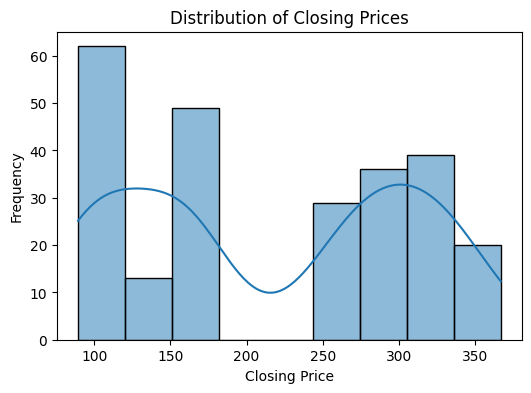

In [9]:
#Distribution of Closing Prices

plt.figure(figsize=(6,4))
sns.histplot(df["Close"], kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()


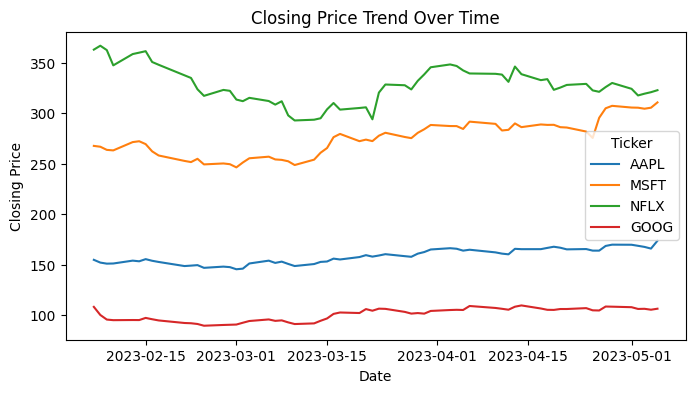

In [10]:
#Stock Prices Over Time (Trend Analysis)

plt.figure(figsize=(8,4))
sns.lineplot(data=df, x="Date", y="Close", hue="Ticker")
plt.title("Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()


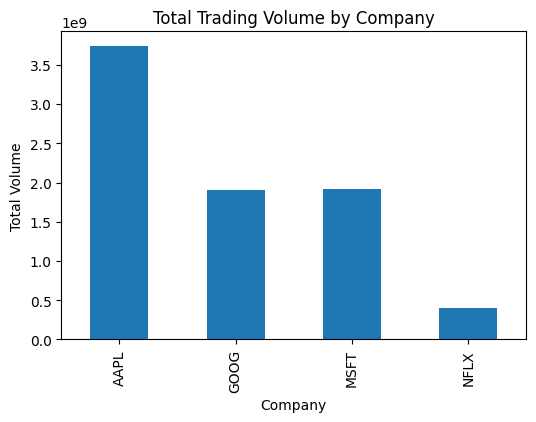

In [11]:
#Trading Volume by Company

plt.figure(figsize=(6,4))
df.groupby("Ticker")["Volume"].sum().plot(kind="bar")
plt.title("Total Trading Volume by Company")
plt.xlabel("Company")
plt.ylabel("Total Volume")
plt.show()


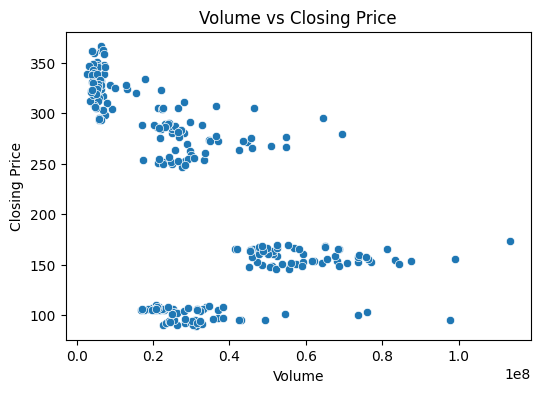

In [12]:
#Volume vs Closing Price

plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Volume"], y=df["Close"])
plt.title("Volume vs Closing Price")
plt.xlabel("Volume")
plt.ylabel("Closing Price")
plt.show()


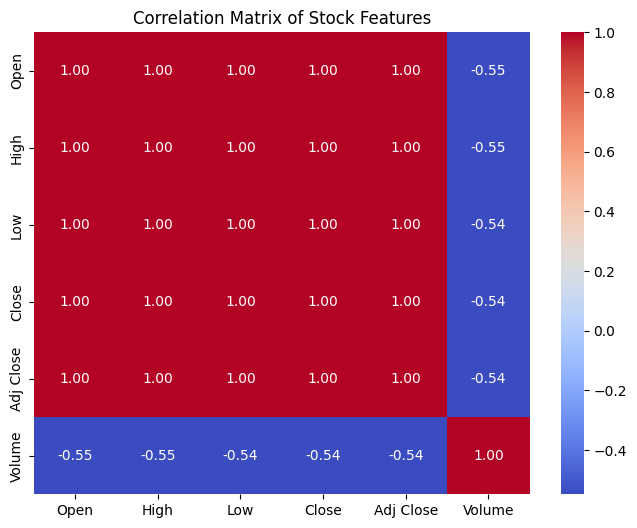

In [13]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[["Open","High","Low","Close","Adj Close","Volume"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Stock Features")
plt.show()


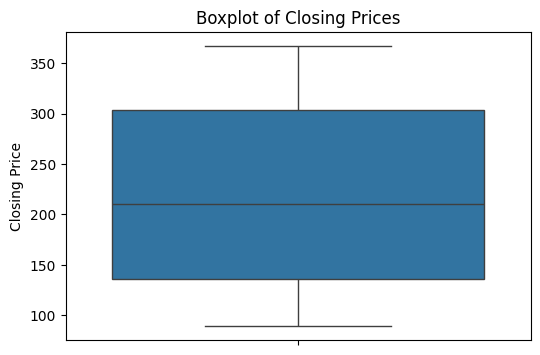

In [14]:
#Outlier Detection (Boxplot)

plt.figure(figsize=(6,4))
sns.boxplot(y=df["Close"])
plt.title("Boxplot of Closing Prices")
plt.ylabel("Closing Price")
plt.show()


Feature Engineering


In [15]:
#Encode Company (Ticker)

df = pd.get_dummies(df, columns=["Ticker"], drop_first=True)


In [16]:
#Feature & Target Split

X = df.drop(columns=["Close", "Date"])
y = df["Close"]


Feature Scaling

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


Machine Learning Models

1. Linear Regression

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


2. Decision Tree Regressor

In [20]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)


3. Random Forest Regressor

In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


4. Gradient Boosting Regressor

In [22]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


Model Evaluation

In [23]:
def evaluate(name, y_true, y_pred):
    print(name)
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))
    print("-"*40)


In [24]:
evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Gradient Boosting", y_test, y_pred_gb)


Linear Regression
MAE: 0.04605613170625588
RMSE: 0.12461522191551175
R2: 0.9999980965799584
----------------------------------------
Decision Tree
MAE: 0.9930020141601551
RMSE: 1.6083731876082403
R2: 0.9996829220099528
----------------------------------------
Random Forest
MAE: 0.7771700317382831
RMSE: 1.0247403527491967
R2: 0.999871287678281
----------------------------------------
Gradient Boosting
MAE: 0.5689492152554289
RMSE: 0.8589131383573616
R2: 0.9999095744957336
----------------------------------------


Feature Importance (Model Interpretability)

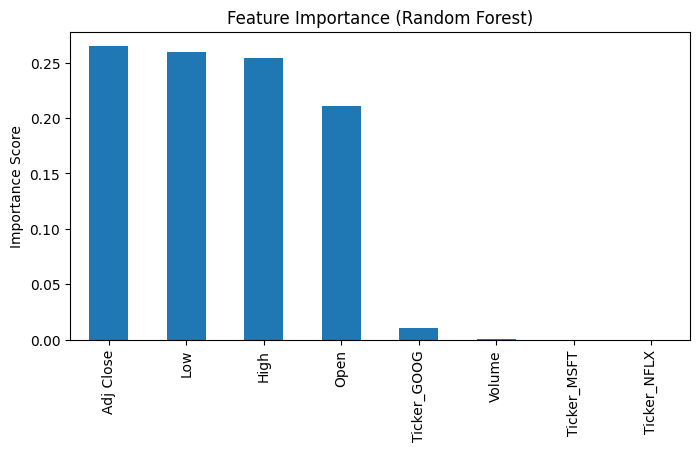

In [25]:
importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,4))
importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()


Prediction vs Actual Plot

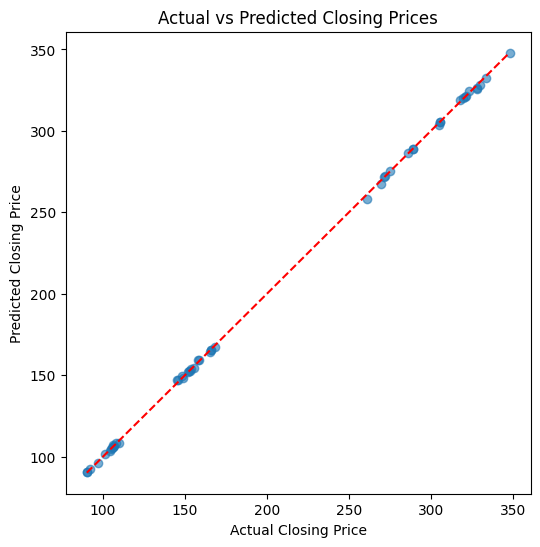

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Actual vs Predicted Closing Prices")
plt.show()


Key Insights

1)Stock prices show strong correlations among Open, High, Low, and Close values

2)Volume shows moderate inverse correlation with price

3)Ensemble models outperform linear models

4)Random Forest and Gradient Boosting provide the most stable predictions

Conclusion

This project demonstrates a complete machine learning workflow for financial data, from exploratory analysis to predictive modeling. The focus is on understanding price dynamics, feature relationships, and model robustness rather than prediction alone.

Technologies Used

Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn